In [1]:
import json
import pandas as pd
import numpy as np
import time
import requests
import osmnx as ox
from haversine import haversine
import itertools
import re
import networkx as nx
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point, LineString
from matplotlib.colors import ListedColormap
from geopy.distance import geodesic

airports_df = pd.read_csv('indiana_airports.csv')
airports_df = airports_df.dropna(subset=['ICAO_ID'])

[0, 35, 34, 30, 33, 25, 24, 26, 28, 32, 48, 47, 14, 44, 22, 23, 9, 10, 31, 27, 29, 37, 38, 36, 43, 41, 40, 42, 39, 17, 20, 18, 19, 15, 16, 21, 13, 50, 8, 7, 12, 5, 6, 4, 11, 49, 3, 2, 46, 45, 1, 0]


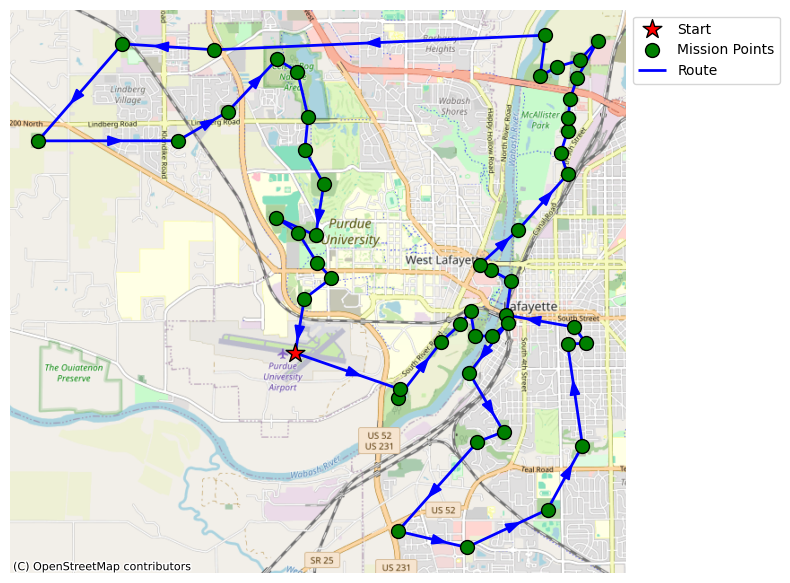

In [3]:
def find_closest_airport(name, airports_df):
    return airports_df['name'].iloc[
        airports_df['name'].str.lower().map(
            lambda x: len(set(x.split()) & set(name.lower().split()))
        ).argmax()
    ]

def get_mission_data(lat, lon, mission, radius):
    gdf = ox.features_from_point((lat, lon), mission, dist=radius)
    gdf = gdf[gdf.index.get_level_values('element_type') == 'way']
    mission_data = []
    for idx, element in gdf.iterrows():
        centroid = element.geometry.centroid
        lat, lon = centroid.y, centroid.x
        mission_info = {
            'name': element.get('name', 'Unknown'),
            'latitude': lat,
            'longitude': lon
        }
        mission_data.append(mission_info)
    return mission_data

def find_optimal_route(mission_data):
    G = nx.complete_graph(len(mission_data))
    for i in range(len(mission_data)):
        for j in range(i+1, len(mission_data)):
            G.edges[i, j]['weight'] = haversine((mission_data[i]['latitude'], mission_data[i]['longitude']), (mission_data[j]['latitude'], mission_data[j]['longitude']))
    
    route = nx.approximation.traveling_salesman_problem(G, cycle=True)
    return route

def plot_routes(mission_data, route):
    fig, ax = plt.subplots(figsize=(8, 8))
    mission_df = pd.DataFrame(mission_data)
    mission_df['type'] = ['Start' if i == 0 else 'Mission' for i in range(len(mission_data))]
    geometry = [Point(p['longitude'], p['latitude']) for p in mission_data]
    mission_gdf = gpd.GeoDataFrame(mission_df, geometry=geometry, crs="EPSG:4326").to_crs(epsg=3857)
    
    airport = mission_gdf[mission_gdf['type'] == 'Start']
    mission = mission_gdf[mission_gdf['type'] == 'Mission']
    airport.plot(ax=ax, color='red', marker='*', markersize=200, edgecolor='black', label='Start', zorder=3)
    mission.plot(ax=ax, color='green', marker='o', markersize=100, edgecolor='black', label='Mission Points', zorder=2)

    route_points = [mission_gdf.geometry.iloc[i] for i in route]
    route_line = gpd.GeoSeries([LineString(route_points)], crs=mission_gdf.crs)
    route_line.plot(ax=ax, color='blue', linewidth=2, linestyle='-', label='Route', zorder=1)
    
    for i in range(len(route)-1):
        from_idx = route[i]
        to_idx = route[i+1]
        from_point = mission_gdf.geometry.iloc[from_idx]
        to_point = mission_gdf.geometry.iloc[to_idx]
        dx = to_point.x - from_point.x
        dy = to_point.y - from_point.y
        distance = (dx**2 + dy**2)**0.5
        if distance > 1000:
            unit_dx = dx / distance
            unit_dy = dy / distance
            arrow_x = from_point.x + dx * 0.5
            arrow_y = from_point.y + dy * 0.5
            plt.arrow(arrow_x, arrow_y, unit_dx*0.1, unit_dy*0.1, head_width=200, head_length=300, fc='blue', ec='blue', zorder=4)
    
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
def save_route_to_txt(mission_data, route, filename):
    ordered_points = []
    for idx in route:
        point = mission_data[idx]
        ordered_points.append([point['latitude'], point['longitude'], 0])
    points_array = np.array(ordered_points)
    np.savetxt(filename, points_array)

def main(start_name, mission, radius):
    start = find_closest_airport(start_name, airports_df)
    start_idx = airports_df[airports_df['name'] == start].index[0]
    start_airport = airports_df.iloc[start_idx]
    mission_data = [{'name': 'airport', 'latitude': start_airport['latitude'], 'longitude': start_airport['longitude']}]
    mission_data.extend(get_mission_data(start_airport['latitude'], start_airport['longitude'], mission, radius))

    route = find_optimal_route(mission_data)
    print(route)
    plot_routes(mission_data, route)
    return mission_data, route

filename = "use_case_1.txt"
mission_data, route = main(start_name="Purdue University", mission={'natural': 'wood'}, radius=5000)
save_route_to_txt(mission_data, route, filename=filename)